In [1]:
import sys, os
import glob
import json
import random
from typing import List, Dict
from dataclasses import dataclass, field
from pathlib import Path

import torch
torch.set_default_dtype(torch.float64)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openmm.app as app

sys.path.insert(0, '..')
from cmm.forcefield import CMMForceField
from cmm.units import HARTREE2KCAL, BOHR2ANG, BOHR2NM
from cmm.develop.data import EdaData2
from cmm.develop.optimize import Trainer2, Optimizer
from cmm.develop.metrics import plot_correlation, plot_eda_scan
from cmm.develop.extract_params import extract_bond_angle_eq, extract_multipoles

### Load Data

In [2]:
data_path = os.path.join("/home/heindelj/research/Teresa/reactive_force_fields/reference_data/CMM_Data/ion_water")

In [3]:
f_water_test_pdb = os.path.join(data_path, "train_test_splits/f_water_wb97xv_qzvppd_test.pdb")
f_water_test_csv = os.path.join(data_path, "train_test_splits/f_water_wb97xv_qzvppd_test.csv")

cl_water_test_pdb = os.path.join(data_path, "train_test_splits/cl_water_wb97xv_qzvppd_test.pdb")
cl_water_test_csv = os.path.join(data_path, "train_test_splits/cl_water_wb97xv_qzvppd_test.csv")

br_water_test_pdb = os.path.join(data_path, "train_test_splits/br_water_wb97xv_qzvppd_test.pdb")
br_water_test_csv = os.path.join(data_path, "train_test_splits/br_water_wb97xv_qzvppd_test.csv")

i_water_test_pdb = os.path.join(data_path, "train_test_splits/i_water_wb97xv_qzvppd_test.pdb")
i_water_test_csv = os.path.join(data_path, "train_test_splits/i_water_wb97xv_qzvppd_test.csv")

li_water_test_pdb = os.path.join(data_path, "train_test_splits/li_water_wb97xv_qzvppd_test.pdb")
li_water_test_csv = os.path.join(data_path, "train_test_splits/li_water_wb97xv_qzvppd_test.csv")

na_water_test_pdb = os.path.join(data_path, "train_test_splits/na_water_wb97xv_qzvppd_test.pdb")
na_water_test_csv = os.path.join(data_path, "train_test_splits/na_water_wb97xv_qzvppd_test.csv")

k_water_test_pdb = os.path.join(data_path, "train_test_splits/k_water_wb97xv_qzvppd_test.pdb")
k_water_test_csv = os.path.join(data_path, "train_test_splits/k_water_wb97xv_qzvppd_test.csv")

rb_water_test_pdb = os.path.join(data_path, "train_test_splits/rb_water_wb97xv_qzvppd_test.pdb")
rb_water_test_csv = os.path.join(data_path, "train_test_splits/rb_water_wb97xv_qzvppd_test.csv")

cs_water_test_pdb = os.path.join(data_path, "train_test_splits/cs_water_wb97xv_qzvppd_test.pdb")
cs_water_test_csv = os.path.join(data_path, "train_test_splits/cs_water_wb97xv_qzvppd_test.csv")

mg_water_test_pdb = os.path.join(data_path, "train_test_splits/mg_water_wb97xv_qzvppd_test.pdb")
mg_water_test_csv = os.path.join(data_path, "train_test_splits/mg_water_wb97xv_qzvppd_test.csv")

ca_water_test_pdb = os.path.join(data_path, "train_test_splits/ca_water_wb97xv_qzvppd_test.pdb")
ca_water_test_csv = os.path.join(data_path, "train_test_splits/ca_water_wb97xv_qzvppd_test.csv")

In [4]:
f_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_f_scan.pdb")
f_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_f_scan.csv")

cl_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_cl_scan.pdb")
cl_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_cl_scan.csv")

br_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_br_scan.pdb")
br_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_br_scan.csv")

i_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_i_scan.pdb")
i_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_i_scan.csv")

li_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_li_scan.pdb")
li_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_li_scan.csv")

na_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_na_scan.pdb")
na_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_na_scan.csv")

k_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_k_scan.pdb")
k_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_k_scan.csv")

rb_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_rb_scan.pdb")
rb_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_rb_scan.csv")

cs_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_cs_scan.pdb")
cs_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_cs_scan.csv")

mg_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_mg_scan.pdb")
mg_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_mg_scan.csv")

ca_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_ca_scan.pdb")
ca_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_ca_scan.csv")

In [5]:
na_cl_scan_pdb = os.path.join(data_path, "ion_ion_scans/na_cl_scan.pdb")
na_cl_scan_csv = os.path.join(data_path, "ion_ion_scans/na_cl_scan.csv")

In [6]:
f_water_test_data = EdaData2.from_csv_file(f_water_test_pdb, f_water_test_csv, num_samples=1000)
#cl_water_test_data = EdaData2.from_csv_file(cl_water_test_pdb, cl_water_test_csv, num_samples=1000)
#br_water_test_data = EdaData2.from_csv_file(br_water_test_pdb, br_water_test_csv, num_samples=1000)
#i_water_test_data = EdaData2.from_csv_file(i_water_test_pdb, i_water_test_csv, num_samples=1000)

#li_water_test_data = EdaData2.from_csv_file(li_water_test_pdb, li_water_test_csv, num_samples=1000)
#na_water_test_data = EdaData2.from_csv_file(na_water_test_pdb, na_water_test_csv, num_samples=1000)
#k_water_test_data = EdaData2.from_csv_file(k_water_test_pdb, k_water_test_csv, num_samples=1000)
#rb_water_test_data = EdaData2.from_csv_file(rb_water_test_pdb, rb_water_test_csv, num_samples=1000)
#cs_water_test_data = EdaData2.from_csv_file(cs_water_test_pdb, cs_water_test_csv, num_samples=1000)
#
#mg_water_test_data = EdaData2.from_csv_file(mg_water_test_pdb, mg_water_test_csv, num_samples=1000)
#ca_water_test_data = EdaData2.from_csv_file(ca_water_test_pdb, ca_water_test_csv, num_samples=1000)

In [7]:
f_water_scan_data = EdaData2.from_csv_file(f_water_scan_pdb, f_water_scan_csv)
cl_water_scan_data = EdaData2.from_csv_file(cl_water_scan_pdb, cl_water_scan_csv)
br_water_scan_data = EdaData2.from_csv_file(br_water_scan_pdb, br_water_scan_csv)
i_water_scan_data = EdaData2.from_csv_file(i_water_scan_pdb, i_water_scan_csv)

li_water_scan_data = EdaData2.from_csv_file(li_water_scan_pdb, li_water_scan_csv)
na_water_scan_data = EdaData2.from_csv_file(na_water_scan_pdb, na_water_scan_csv)
k_water_scan_data = EdaData2.from_csv_file(k_water_scan_pdb, k_water_scan_csv)
rb_water_scan_data = EdaData2.from_csv_file(rb_water_scan_pdb, rb_water_scan_csv)
cs_water_scan_data = EdaData2.from_csv_file(cs_water_scan_pdb, cs_water_scan_csv)

mg_water_scan_data = EdaData2.from_csv_file(mg_water_scan_pdb, mg_water_scan_csv)
ca_water_scan_data = EdaData2.from_csv_file(ca_water_scan_pdb, ca_water_scan_csv)

In [8]:
na_cl_scan_data = EdaData2.from_csv_file(na_cl_scan_pdb, na_cl_scan_csv)

### Create Force Field

In [9]:
ff = CMMForceField(os.path.join(os.path.abspath(''), "../tests/data/ion_water_params_8_19.json"))

optimizer = Optimizer(
    ff
)

trainer = Trainer2(
    ff, optimizer
)

### Plotting Functions

In [10]:
def report_eda_cluster(trainer, data, **kwargs):
    with torch.no_grad():
        res, ref = trainer.evaluate(data)
    
    keys = ['total', 'perm_elec', 'pol', 'ct', 'pauli', 'disp']
    fig, axes = plt.subplots(2, 3, figsize=(9, 6), constrained_layout=True)
    axes = axes.flatten()
    for i in range(len(keys)):
        ax = axes[i]
        key = keys[i]
        if key == 'total':
            plot_correlation(ref['int'], res[key], xlabel='QM (kcal/mol)', ylabel='CMM (kcal/mol)', ax=ax)
        else:
            plot_correlation(ref[key], res[key], xlabel='QM (kcal/mol)', ylabel='CMM (kcal/mol)', ax=ax)
        ax.set_title(key.upper())
    return fig

def report_eda_scan(trainer, data, **kwargs):
    with torch.no_grad():
        res, ref = trainer.evaluate(data)
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes = axes.flatten()
    if 'distances' in data.eda_df:
        xdata = data.eda_df['distances'].to_numpy()
        xlabel = "Distance (A)"
    else:
        xdata=np.linspace(1, len(ref['int']), len(ref['int']), dtype=np.int64)
        xlabel = "k_index"
    keys = ['perm_elec', 'pauli', 'disp', 'pol', 'ct', 'total']

    plot_eda_scan(xdata, {'total': ref['int']}, {'total': res['total']}, ax=axes[0], keys=['total'], xmax=5, ymax=0, xlabel=xlabel)
    
    ref['total'] = ref['int']
    with torch.no_grad():
        error = {key: res[key] - ref[key] for key in keys}
    plot_eda_scan(xdata, error, ylabel='Energy Error (kcal/mol)', ax=axes[1], xmax=5, xlabel=xlabel)
    return fig

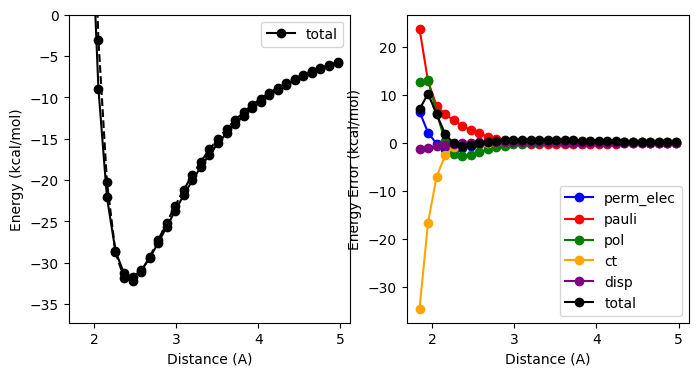

In [11]:
f_water_scan_fig = report_eda_scan(trainer, f_water_scan_data)

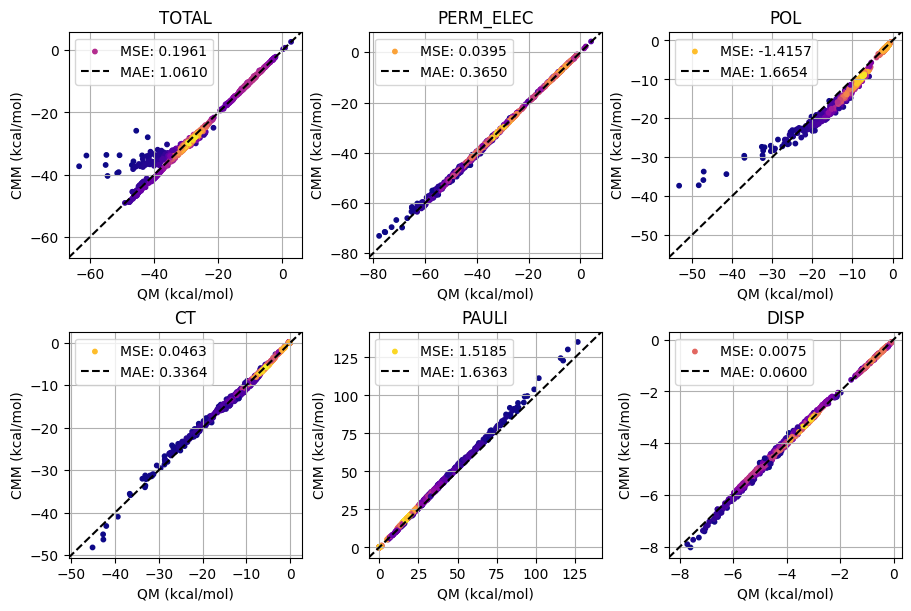

In [12]:
f_water_test_fig = report_eda_cluster(trainer, f_water_test_data)

/home/heindelj/OneDrive/Documents/Coding_Projects/python_development/pyCMM/notebooks/../cmm/forcefield.py:732: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  bond_pairs = torch.tensor(bond_pairs, dtype=torch.long).T


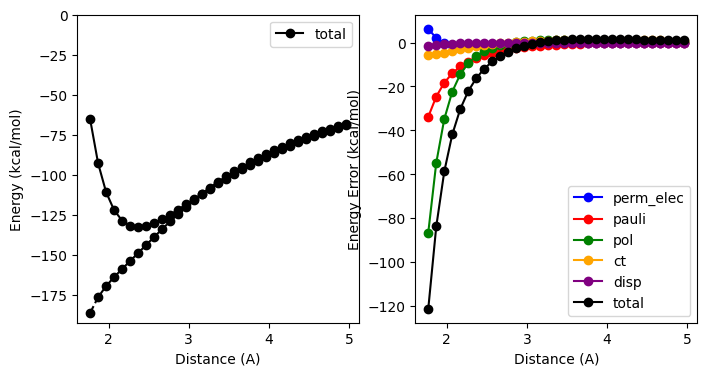

In [13]:
na_cl_scan_fig = report_eda_scan(trainer, na_cl_scan_data)